In [1]:
import pandas as pd

df = pd.read_csv('/content/inventory_forecasting.csv')

print("--- DATA INFO ---")
df.info()

print("\n--- FIRST 5 ROWS ---")
display(df.head())

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109500 entries, 0 to 109499
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                109500 non-null  object 
 1   Store ID            109500 non-null  object 
 2   Product ID          109500 non-null  object 
 3   Category            109500 non-null  object 
 4   Region              109500 non-null  object 
 5   Inventory Level     109500 non-null  int64  
 6   Units Sold          109500 non-null  int64  
 7   Units Ordered       109500 non-null  int64  
 8   Demand Forecast     109500 non-null  float64
 9   Price               109500 non-null  float64
 10  Discount            109500 non-null  int64  
 11  Weather Condition   109500 non-null  object 
 12  Holiday/Promotion   109500 non-null  int64  
 13  Competitor Pricing  109500 non-null  float64
 14  Seasonality         109500 non-null  object 
dtypes: float64(3), i

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0096,Toys,West,158,134,142,152.36,40.88,5,Sunny,1,42.39,Winter
1,2022-01-01,S001,P0016,Clothing,East,189,127,125,150.47,90.78,0,Rainy,0,84.16,Winter
2,2022-01-01,S001,P0031,Electronics,West,75,48,39,68.62,13.99,20,Rainy,0,12.67,Winter
3,2022-01-01,S001,P0159,Electronics,West,161,74,71,75.46,84.92,10,Snowy,0,83.03,Winter
4,2022-01-01,S001,P0129,Furniture,South,135,66,69,67.18,19.66,0,Cloudy,0,20.55,Winter


In [2]:
#database normalization

import sqlite3
import pandas as pd

conn = sqlite3.connect('inventory_db.sqlite')

stores_df = df[['Store ID', 'Region']].drop_duplicates().reset_index(drop=True)
stores_df.to_sql('Stores', conn, if_exists='replace', index=False)

products_df = df[['Product ID', 'Category', 'Price']].drop_duplicates(subset=['Product ID']).reset_index(drop=True)
products_df.to_sql('Products', conn, if_exists='replace', index=False)

fact_cols = [
    'Date', 'Store ID', 'Product ID', 'Inventory Level', 'Units Sold',
    'Units Ordered', 'Demand Forecast', 'Discount', 'Holiday/Promotion',
    'Competitor Pricing', 'Seasonality'
]
fact_df = df[fact_cols]
fact_df.to_sql('Inventory_Log', conn, if_exists='replace', index=False)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
display(tables)

,name
0,Stores
1,Products
2,Inventory_Log


In [3]:
#sql analytics and optimization

query_stock_levels = """
SELECT
    p.Category,
    i.[Product ID],
    s.Region,
    SUM(i.[Inventory Level]) as Total_Current_Stock,
    AVG(i.[Inventory Level]) as Avg_Daily_Stock
FROM Inventory_Log i
JOIN Products p ON i.[Product ID] = p.[Product ID]
JOIN Stores s ON i.[Store ID] = s.[Store ID]
GROUP BY p.Category, i.[Product ID], s.Region
ORDER BY Total_Current_Stock DESC
LIMIT 10;
"""
display(pd.read_sql(query_stock_levels, conn))

query_turnover = """
WITH ProductStats AS (
    SELECT
        [Product ID],
        SUM([Units Sold]) as Total_Sold,
        AVG([Inventory Level]) as Avg_Inventory
    FROM Inventory_Log
    GROUP BY [Product ID]
)
SELECT
    [Product ID],
    Total_Sold,
    Avg_Inventory,
    CASE
        WHEN Avg_Inventory > 0 THEN Total_Sold / Avg_Inventory
        ELSE 0
    END as Inventory_Turnover_Ratio
FROM ProductStats
ORDER BY Inventory_Turnover_Ratio DESC
LIMIT 10;
"""
display(pd.read_sql(query_turnover, conn))

query_reorder = """
WITH DailySales AS (
    SELECT
        [Product ID],
        AVG([Units Sold]) as Avg_Daily_Sales,
        MIN([Inventory Level]) as Current_Min_Inventory
    FROM Inventory_Log
    GROUP BY [Product ID]
)
SELECT
    p.[Product ID],
    p.Category,
    ROUND(d.Avg_Daily_Sales, 2) as Avg_Daily_Sales,
    ROUND((d.Avg_Daily_Sales * 7), 2) as Est_Reorder_Point,
    d.Current_Min_Inventory,
    CASE
        WHEN d.Current_Min_Inventory < (d.Avg_Daily_Sales * 7) THEN 'High Risk'
        ELSE 'Healthy'
    END as Stockout_Risk
FROM DailySales d
JOIN Products p ON d.[Product ID] = p.[Product ID]
ORDER BY d.Avg_Daily_Sales DESC
LIMIT 10;
"""
display(pd.read_sql(query_reorder, conn))

,Category,Product ID,Region,Total_Current_Stock,Avg_Daily_Stock
0,Clothing,P0016,East,566557,155.221096
1,Clothing,P0016,North,566557,155.221096
2,Clothing,P0016,South,566557,155.221096
3,Clothing,P0016,West,566557,155.221096
4,Clothing,P0057,East,566071,155.087945
5,Clothing,P0057,North,566071,155.087945
6,Clothing,P0057,South,566071,155.087945
7,Clothing,P0057,West,566071,155.087945
8,Clothing,P0125,East,565320,154.882192
9,Clothing,P0125,North,565320,154.882192


,Product ID,Total_Sold,Avg_Inventory,Inventory_Turnover_Ratio
0,P0046,386805,154.506301,2503.490127
1,P0133,385843,154.356986,2499.679537
2,P0057,387209,155.087945,2496.705979
3,P0178,384440,153.986575,2496.581271
4,P0187,385583,154.869315,2489.731422
5,P0066,384764,154.667123,2487.690931
6,P0125,385137,154.882192,2486.644821
7,P0061,384668,154.775342,2485.331280
8,P0069,382968,154.473151,2479.188120
9,P0016,384509,155.221096,2477.169729


,Product ID,Category,Avg_Daily_Sales,Est_Reorder_Point,Current_Min_Inventory,Stockout_Risk
0,P0057,Clothing,106.08,742.59,20,High Risk
1,P0046,Clothing,105.97,741.82,20,High Risk
2,P0133,Clothing,105.71,739.97,30,High Risk
3,P0187,Clothing,105.64,739.47,21,High Risk
4,P0125,Clothing,105.52,738.62,21,High Risk
5,P0066,Clothing,105.41,737.90,24,High Risk
6,P0061,Clothing,105.39,737.72,23,High Risk
7,P0016,Clothing,105.34,737.41,21,High Risk
8,P0178,Clothing,105.33,737.28,23,High Risk
9,P0069,Clothing,104.92,734.46,25,High Risk


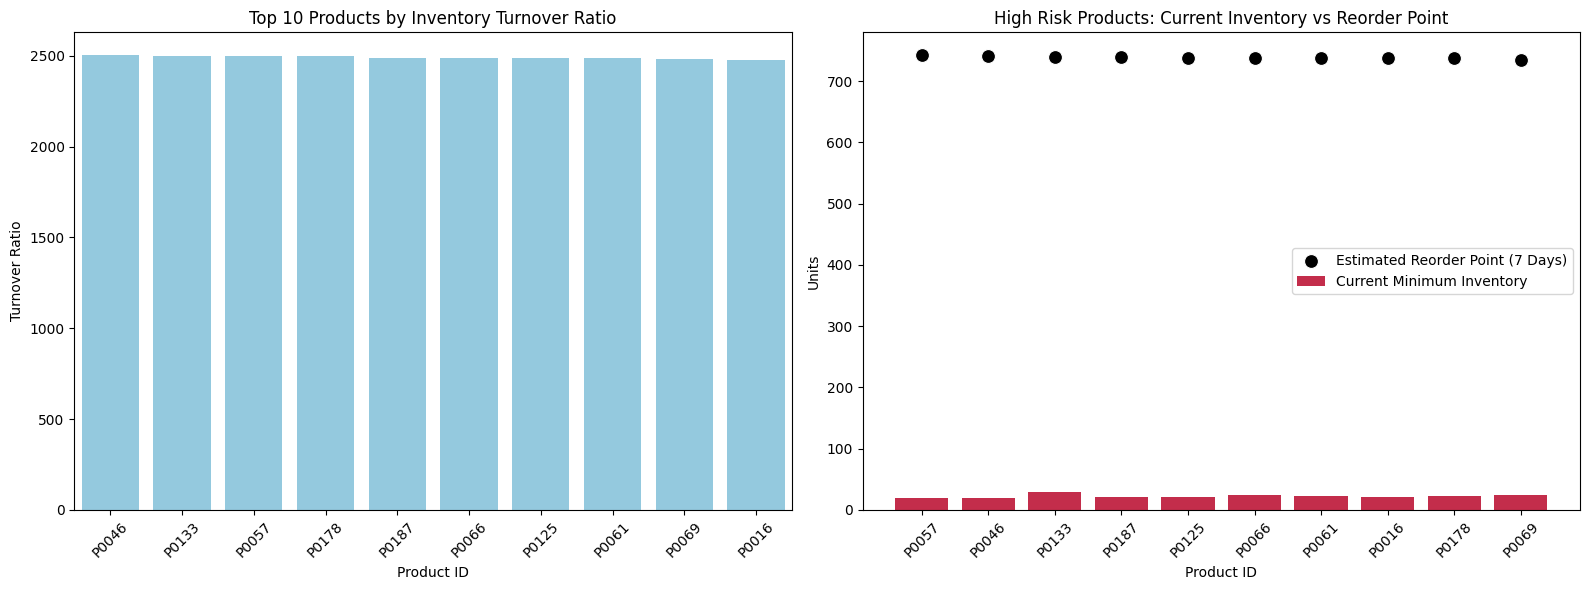

In [4]:
#analytical outputs and dashboards

import matplotlib.pyplot as plt
import seaborn as sns

turnover_df = pd.read_sql(query_turnover, conn)
reorder_df = pd.read_sql(query_reorder, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=turnover_df, x='Product ID', y='Inventory_Turnover_Ratio', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Products by Inventory Turnover Ratio')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Turnover Ratio')

high_risk = reorder_df[reorder_df['Stockout_Risk'] == 'High Risk'].head(10)
sns.barplot(data=high_risk, x='Product ID', y='Current_Min_Inventory', ax=axes[1], color='crimson', label='Current Minimum Inventory')
sns.scatterplot(data=high_risk, x='Product ID', y='Est_Reorder_Point', ax=axes[1], color='black', s=100, label='Estimated Reorder Point (7 Days)')
axes[1].set_title('High Risk Products: Current Inventory vs Reorder Point')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Units')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
query_kpi_summary = """
WITH DailyMetrics AS (
    SELECT
        p.Category,
        i.[Product ID],
        COUNT(i.Date) as Total_Days_Recorded,
        -- Count how many days the inventory dropped to 0 or below
        SUM(CASE WHEN i.[Inventory Level] <= 0 THEN 1 ELSE 0 END) as Stockout_Days,
        AVG(i.[Inventory Level]) as Avg_Stock_Level,
        SUM(i.[Units Sold]) as Total_Sold
    FROM Inventory_Log i
    JOIN Products p ON i.[Product ID] = p.[Product ID]
    GROUP BY p.Category, i.[Product ID]
)
SELECT
    Category,
    COUNT([Product ID]) as Total_SKUs_in_Category,
    ROUND(AVG(Avg_Stock_Level), 0) as Average_Stock_Level,
    SUM(Total_Sold) as Total_Units_Sold,
    -- Calculate the stockout rate as a percentage
    ROUND((CAST(SUM(Stockout_Days) AS FLOAT) / SUM(Total_Days_Recorded)) * 100, 2) as Stockout_Rate_Percent
FROM DailyMetrics
GROUP BY Category
ORDER BY Stockout_Rate_Percent DESC;
"""

kpi_df = pd.read_sql(query_kpi_summary, conn)

print("--- EXECUTIVE KPI SUMMARY BY CATEGORY ---")
display(kpi_df)

--- EXECUTIVE KPI SUMMARY BY CATEGORY ---


,Category,Total_SKUs_in_Category,Average_Stock_Level,Total_Units_Sold,Stockout_Rate_Percent
0,Toys,3,142.0,1018493,0.0
1,Groceries,2,149.0,729550,0.0
2,Furniture,6,142.0,2035351,0.0
3,Electronics,8,137.0,2577043,0.0
4,Clothing,11,155.0,4230880,0.0


In [6]:
query_kpi_summary_updated = """
WITH DailyMetrics AS (
    SELECT
        p.Category,
        i.[Product ID],
        COUNT(i.Date) as Total_Days_Recorded,
        -- Changed threshold: Count days where inventory dropped to 50 or below
        SUM(CASE WHEN i.[Inventory Level] <= 50 THEN 1 ELSE 0 END) as Critically_Low_Days,
        AVG(i.[Inventory Level]) as Avg_Stock_Level,
        SUM(i.[Units Sold]) as Total_Sold
    FROM Inventory_Log i
    JOIN Products p ON i.[Product ID] = p.[Product ID]
    GROUP BY p.Category, i.[Product ID]
)
SELECT
    Category,
    COUNT([Product ID]) as Total_SKUs_in_Category,
    ROUND(AVG(Avg_Stock_Level), 0) as Average_Stock_Level,
    SUM(Total_Sold) as Total_Units_Sold,
    -- Calculate the critically low rate as a percentage
    ROUND((CAST(SUM(Critically_Low_Days) AS FLOAT) / SUM(Total_Days_Recorded)) * 100, 2) as Critical_Stock_Rate_Percent
FROM DailyMetrics
GROUP BY Category
ORDER BY Critical_Stock_Rate_Percent DESC;
"""

kpi_df_updated = pd.read_sql(query_kpi_summary_updated, conn)

print("--- UPDATED KPI SUMMARY: CRITICALLY LOW STOCK ---")
display(kpi_df_updated)

--- UPDATED KPI SUMMARY: CRITICALLY LOW STOCK ---


,Category,Total_SKUs_in_Category,Average_Stock_Level,Total_Units_Sold,Critical_Stock_Rate_Percent
0,Electronics,8,137.0,2577043,1.61
1,Toys,3,142.0,1018493,1.44
2,Furniture,6,142.0,2035351,1.33
3,Groceries,2,149.0,729550,1.01
4,Clothing,11,155.0,4230880,0.99


In [7]:
cursor = conn.cursor()
cursor.execute("CREATE INDEX IF NOT EXISTS idx_inv_product ON Inventory_Log([Product ID]);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_inv_store ON Inventory_Log([Store ID]);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_inv_date ON Inventory_Log(Date);")
conn.commit()


In [8]:
query_fast_vs_slow = """
WITH ProductVelocity AS (
    SELECT
        p.Category,
        i.[Product ID],
        SUM(i.[Units Sold]) as Total_Units_Sold,
        RANK() OVER (PARTITION BY p.Category ORDER BY SUM(i.[Units Sold]) DESC) as Fast_Rank,
        RANK() OVER (PARTITION BY p.Category ORDER BY SUM(i.[Units Sold]) ASC) as Slow_Rank
    FROM Inventory_Log i
    JOIN Products p ON i.[Product ID] = p.[Product ID]
    GROUP BY p.Category, i.[Product ID]
)
SELECT
    Category,
    [Product ID],
    Total_Units_Sold,
    CASE
        WHEN Fast_Rank <= 2 THEN 'Fast-Selling'
        WHEN Slow_Rank <= 2 THEN 'Slow-Moving'
        ELSE 'Average'
    END as Product_Velocity_Status
FROM ProductVelocity
WHERE Fast_Rank <= 2 OR Slow_Rank <= 2
ORDER BY Category, Total_Units_Sold DESC;
"""
print("--- FAST-SELLING VS SLOW-MOVING PRODUCTS ---")
display(pd.read_sql(query_fast_vs_slow, conn))

query_stock_adjustments = """
WITH OverstockCheck AS (
    SELECT
        [Product ID],
        AVG([Inventory Level]) as Avg_Inventory,
        AVG([Units Sold]) as Avg_Daily_Sales
    FROM Inventory_Log
    GROUP BY [Product ID]
)
SELECT
    o.[Product ID],
    p.Category,
    ROUND(o.Avg_Inventory, 1) as Avg_Inventory_On_Hand,
    ROUND(o.Avg_Daily_Sales, 1) as Avg_Daily_Sales,
    ROUND(o.Avg_Inventory / NULLIF(o.Avg_Daily_Sales, 0), 1) as Days_Of_Supply,
    CASE
        WHEN (o.Avg_Inventory / NULLIF(o.Avg_Daily_Sales, 0)) > 30 THEN 'Reduce Stock / Holding Cost Risk'
        WHEN (o.Avg_Inventory / NULLIF(o.Avg_Daily_Sales, 0)) < 7 THEN 'Increase Stock / Stockout Risk'
        ELSE 'Optimal'
    END as Recommended_Action
FROM OverstockCheck o
JOIN Products p ON o.[Product ID] = p.[Product ID]
ORDER BY Days_Of_Supply DESC
LIMIT 10;
"""
print("\n--- STOCK ADJUSTMENT RECOMMENDATIONS (REDUCING HOLDING COSTS) ---")
display(pd.read_sql(query_stock_adjustments, conn))

query_supply_gaps = """
SELECT
    [Product ID],
    SUM([Units Ordered]) as Total_Units_Ordered,
    SUM([Units Sold]) as Total_Units_Sold,
    SUM([Units Ordered]) - SUM([Units Sold]) as Net_Supply_Variance,
    ROUND(AVG([Inventory Level]), 1) as Avg_Daily_Inventory
FROM Inventory_Log
GROUP BY [Product ID]
ORDER BY Net_Supply_Variance ASC
LIMIT 10;
"""
print("\n--- SUPPLIER PERFORMANCE & SUPPLY GAP INCONSISTENCIES ---")
display(pd.read_sql(query_supply_gaps, conn))

query_seasonality_demand = """
SELECT
    Seasonality,
    [Holiday/Promotion],
    ROUND(AVG([Units Sold]), 2) as Avg_Units_Sold,
    ROUND(AVG([Demand Forecast]), 2) as Avg_Forecasted_Demand,
    ROUND(AVG([Units Sold]) - AVG([Demand Forecast]), 2) as Forecast_Error
FROM Inventory_Log
GROUP BY Seasonality, [Holiday/Promotion]
ORDER BY Avg_Units_Sold DESC;
"""
print("\n--- SEASONAL & CYCLICAL DEMAND TRENDS ---")
display(pd.read_sql(query_seasonality_demand, conn))

--- FAST-SELLING VS SLOW-MOVING PRODUCTS ---


,Category,Product ID,Total_Units_Sold,Product_Velocity_Status
0,Clothing,P0057,387209,Fast-Selling
1,Clothing,P0046,386805,Fast-Selling
2,Clothing,P0069,382968,Slow-Moving
3,Clothing,P0126,378954,Slow-Moving
4,Electronics,P0171,325546,Fast-Selling
5,Electronics,P0183,325516,Fast-Selling
6,Electronics,P0070,320229,Slow-Moving
7,Electronics,P0068,317668,Slow-Moving
8,Furniture,P0067,340306,Fast-Selling
9,Furniture,P0153,339595,Fast-Selling



--- STOCK ADJUSTMENT RECOMMENDATIONS (REDUCING HOLDING COSTS) ---


,Product ID,Category,Avg_Inventory_On_Hand,Avg_Daily_Sales,Days_Of_Supply,Recommended_Action
0,P0070,Electronics,137.8,87.7,1.6,Increase Stock / Stockout Risk
1,P0171,Electronics,138.9,89.2,1.6,Increase Stock / Stockout Risk
2,P0175,Electronics,137.0,88.3,1.6,Increase Stock / Stockout Risk
3,P0183,Electronics,138.5,89.2,1.6,Increase Stock / Stockout Risk
4,P0085,Electronics,136.5,87.7,1.6,Increase Stock / Stockout Risk
5,P0068,Electronics,135.4,87.0,1.6,Increase Stock / Stockout Risk
6,P0096,Toys,142.0,93.0,1.5,Increase Stock / Stockout Risk
7,P0016,Clothing,155.2,105.3,1.5,Increase Stock / Stockout Risk
8,P0031,Electronics,136.8,88.4,1.5,Increase Stock / Stockout Risk
9,P0159,Electronics,136.6,88.4,1.5,Increase Stock / Stockout Risk



--- SUPPLIER PERFORMANCE & SUPPLY GAP INCONSISTENCIES ---


,Product ID,Total_Units_Ordered,Total_Units_Sold,Net_Supply_Variance,Avg_Daily_Inventory
0,P0159,319414,322605,-3191,136.6
1,P0149,335590,338505,-2915,141.4
2,P0096,336619,339338,-2719,142.0
3,P0046,384246,386805,-2559,154.5
4,P0171,323025,325546,-2521,138.9
5,P0070,318057,320229,-2172,137.8
6,P0066,382594,384764,-2170,154.7
7,P0094,362996,365157,-2161,149.1
8,P0153,337473,339595,-2122,141.0
9,P0031,320751,322746,-1995,136.8



--- SEASONAL & CYCLICAL DEMAND TRENDS ---


,Seasonality,Holiday/Promotion,Avg_Units_Sold,Avg_Forecasted_Demand,Forecast_Error
0,Winter,1,123.06,137.35,-14.29
1,Summer,1,109.76,122.44,-12.68
2,Spring,1,107.76,120.30,-12.53
3,Autumn,1,106.74,119.37,-12.63
4,Winter,0,102.04,113.90,-11.86
5,Summer,0,90.91,101.60,-10.70
6,Spring,0,89.20,99.51,-10.32
7,Autumn,0,89.17,99.58,-10.41


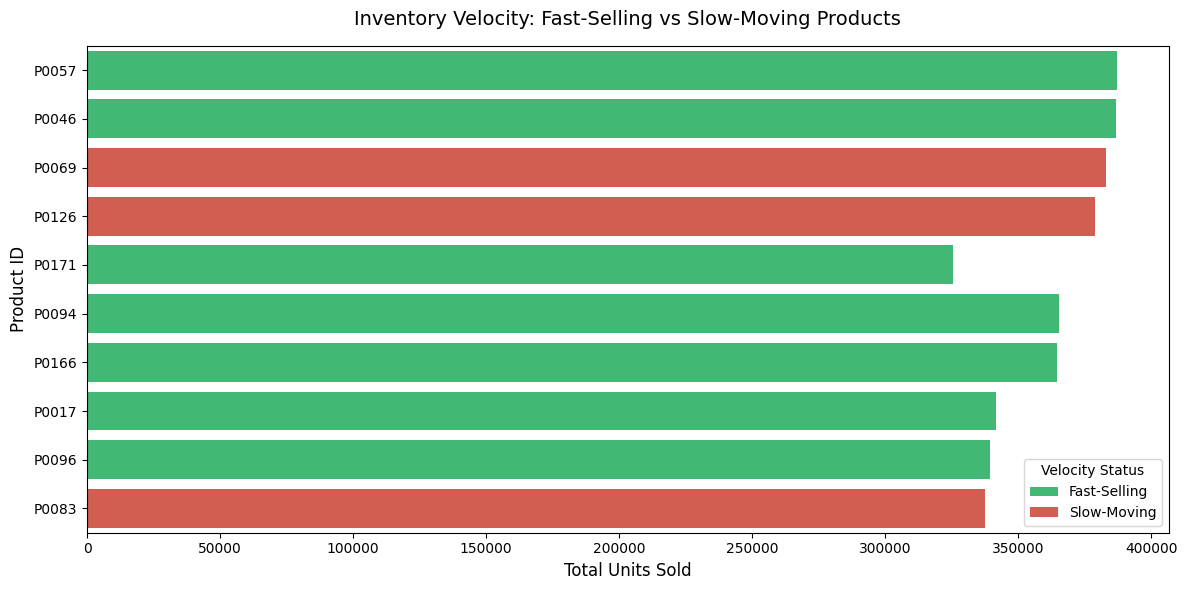

In [9]:
#1. Visualizing Product Velocity (Fast vs. Slow)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data from your existing SQLite connection
df_fast_slow = pd.read_sql(query_fast_vs_slow, conn)

# Filter for a clean visualization (Top 5 Fast, Top 5 Slow)
df_viz_1 = pd.concat([df_fast_slow.head(5), df_fast_slow.tail(5)])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_viz_1,
    x='Total_Units_Sold',
    y='Product ID',
    hue='Product_Velocity_Status',
    palette={'Fast-Selling': '#2ecc71', 'Slow-Moving': '#e74c3c'},
    dodge=False
)
plt.title('Inventory Velocity: Fast-Selling vs Slow-Moving Products', fontsize=14, pad=15)
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product ID', fontsize=12)
plt.legend(title='Velocity Status')
plt.tight_layout()
plt.show()

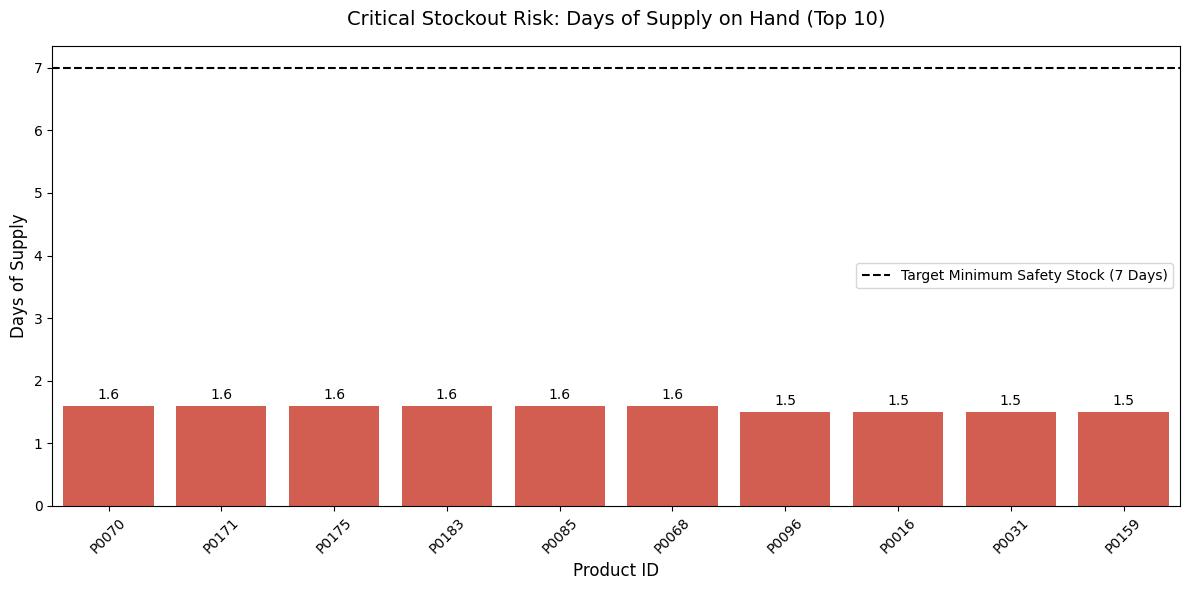

In [10]:
#2. Visualizing Stockout Risk (Days of Supply)

df_stock = pd.read_sql(query_stock_adjustments, conn)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_stock,
    x='Product ID',
    y='Days_Of_Supply',
    color='#e74c3c'
)
plt.axhline(y=7, color='black', linestyle='--', label='Target Minimum Safety Stock (7 Days)')
plt.title('Critical Stockout Risk: Days of Supply on Hand (Top 10)', fontsize=14, pad=15)
plt.xlabel('Product ID', fontsize=12)
plt.ylabel('Days of Supply', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# Add data labels on top of the bars for clarity
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

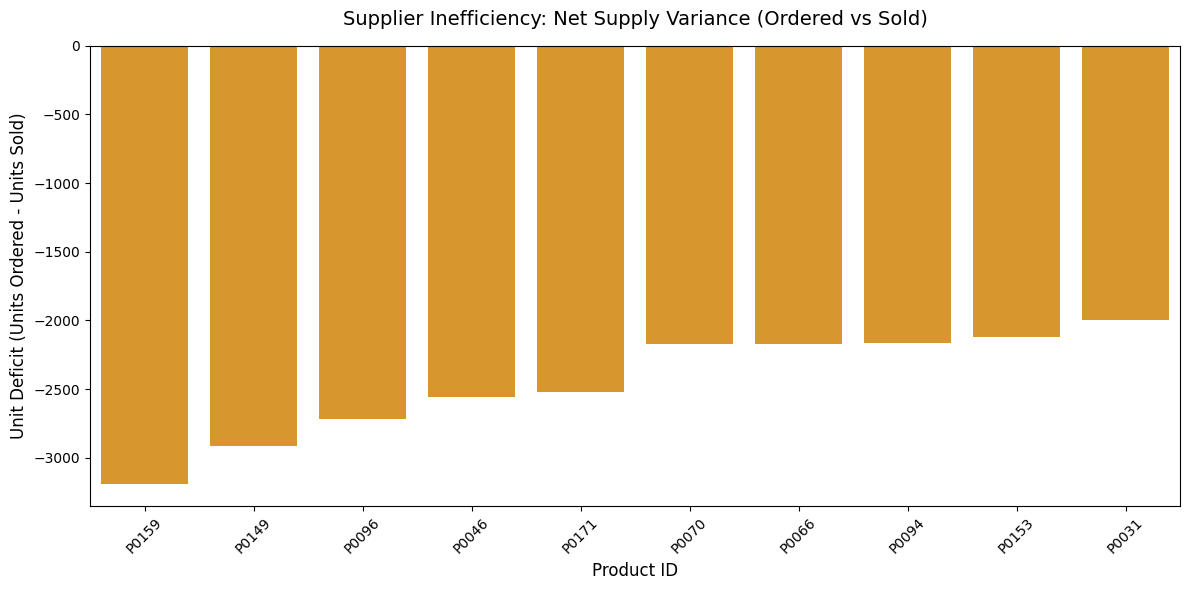

In [11]:
#3. Visualizing the Supply Gap

df_gap = pd.read_sql(query_supply_gaps, conn)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_gap,
    x='Product ID',
    y='Net_Supply_Variance',
    color='#f39c12'
)
plt.title('Supplier Inefficiency: Net Supply Variance (Ordered vs Sold)', fontsize=14, pad=15)
plt.xlabel('Product ID', fontsize=12)
plt.ylabel('Unit Deficit (Units Ordered - Units Sold)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

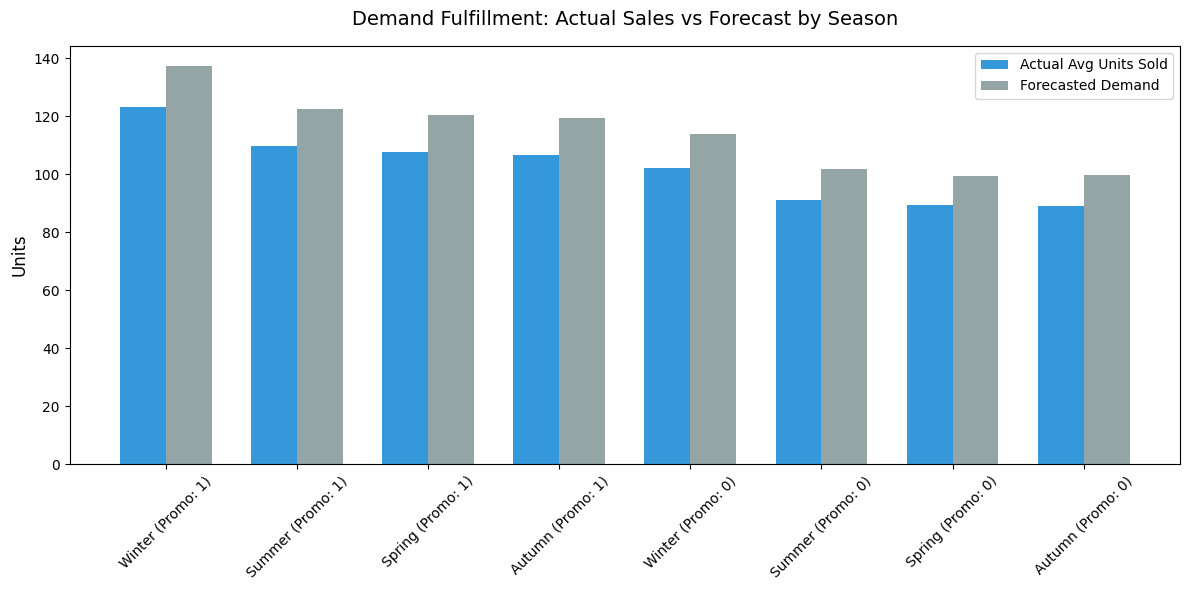

In [12]:
#4. Visualizing Seasonality & Forecast Accuracy

import numpy as np

df_season = pd.read_sql(query_seasonality_demand, conn)

# Set up the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_season['Seasonality']))
width = 0.35

rects1 = ax.bar(x - width/2, df_season['Avg_Units_Sold'], width, label='Actual Avg Units Sold', color='#3498db')
rects2 = ax.bar(x + width/2, df_season['Avg_Forecasted_Demand'], width, label='Forecasted Demand', color='#95a5a6')

ax.set_ylabel('Units', fontsize=12)
ax.set_title('Demand Fulfillment: Actual Sales vs Forecast by Season', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_season['Seasonality'] + ' (Promo: ' + df_season['Holiday/Promotion'].astype(str) + ')')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5412/3236484159.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


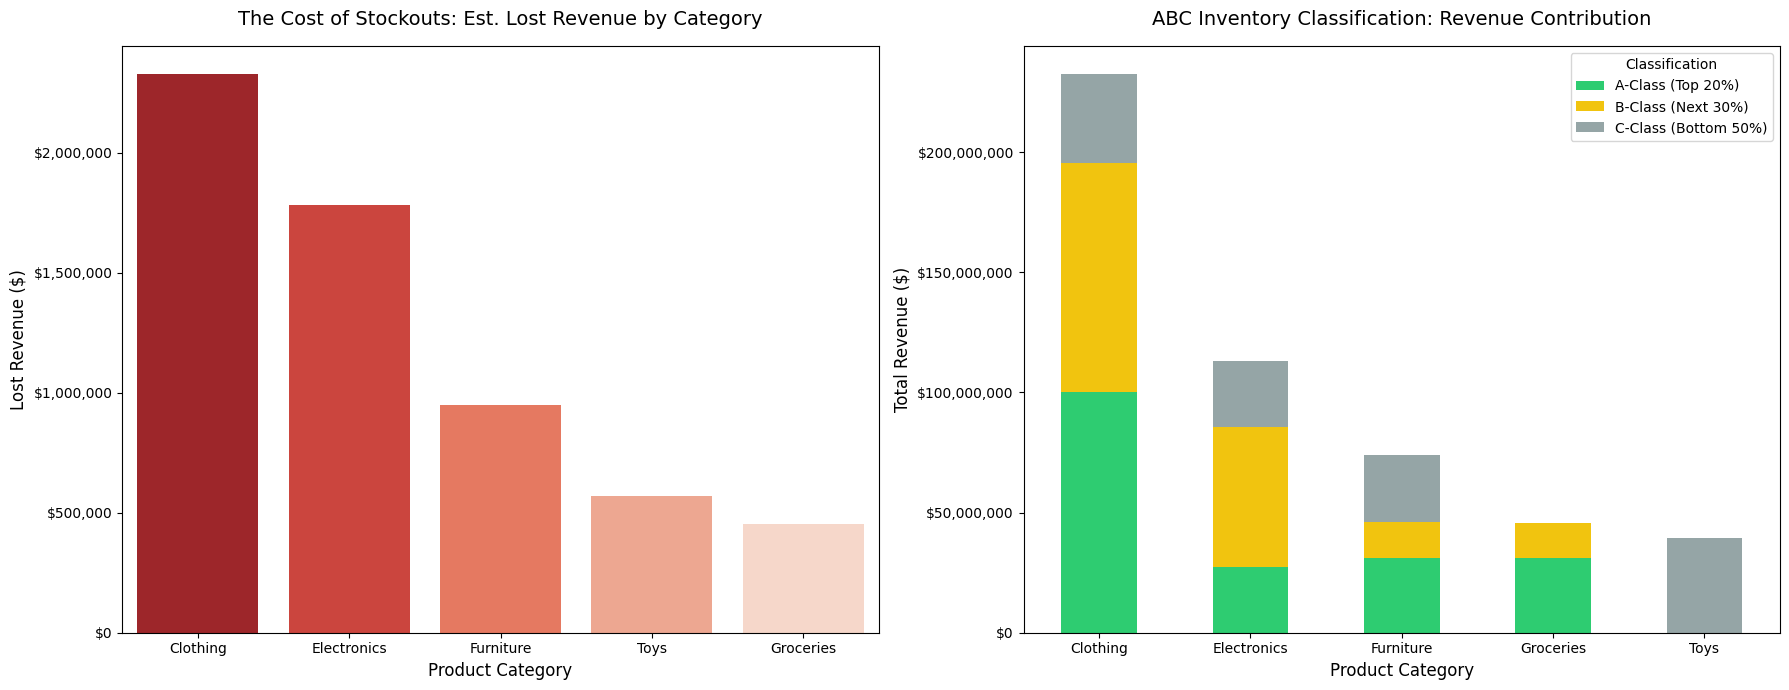

In [13]:
#5. Estimated Lost Revenue & ABC Inventory Classification (The Pareto Principle)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. EST. LOST REVENUE FROM STOCKOUTS
query_lost_revenue = """
WITH HealthySales AS (
    SELECT [Product ID], AVG([Units Sold]) as Daily_Sales_Pace
    FROM Inventory_Log
    WHERE [Inventory Level] > 50
    GROUP BY [Product ID]
),
StockoutImpact AS (
    SELECT i.[Product ID], COUNT(i.Date) as Missed_Days
    FROM Inventory_Log i
    WHERE i.[Inventory Level] <= 50
    GROUP BY i.[Product ID]
)
SELECT
    p.Category,
    ROUND(SUM(s.Missed_Days * h.Daily_Sales_Pace * p.Price), 2) as Estimated_Lost_Revenue
FROM StockoutImpact s
JOIN HealthySales h ON s.[Product ID] = h.[Product ID]
JOIN Products p ON s.[Product ID] = p.[Product ID]
GROUP BY p.Category
ORDER BY Estimated_Lost_Revenue DESC;
"""
df_lost_rev = pd.read_sql(query_lost_revenue, conn)

# 2. ABC INVENTORY CLASSIFICATION
query_abc = """
WITH ProductRevenue AS (
    SELECT
        i.[Product ID],
        p.Category,
        SUM(i.[Units Sold] * p.Price) as Total_Revenue
    FROM Inventory_Log i
    JOIN Products p ON i.[Product ID] = p.[Product ID]
    GROUP BY i.[Product ID], p.Category
),
RankedRevenue AS (
    SELECT
        [Product ID],
        Category,
        Total_Revenue,
        PERCENT_RANK() OVER (ORDER BY Total_Revenue DESC) as Revenue_Percentile
    FROM ProductRevenue
)
SELECT
    Category,
    CASE
        WHEN Revenue_Percentile <= 0.20 THEN 'A-Class (Top 20%)'
        WHEN Revenue_Percentile <= 0.50 THEN 'B-Class (Next 30%)'
        ELSE 'C-Class (Bottom 50%)'
    END as ABC_Classification,
    ROUND(SUM(Total_Revenue), 2) as Total_Category_Revenue
FROM RankedRevenue
GROUP BY Category, ABC_Classification
ORDER BY Category, ABC_Classification;
"""
df_abc = pd.read_sql(query_abc, conn)

# --- VISUALIZATION SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Lost Revenue
sns.barplot(
    data=df_lost_rev,
    x='Category',
    y='Estimated_Lost_Revenue',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('The Cost of Stockouts: Est. Lost Revenue by Category', fontsize=14, pad=15)
axes[0].set_ylabel('Lost Revenue ($)', fontsize=12)
axes[0].set_xlabel('Product Category', fontsize=12)

# Format y-axis as currency for Chart 1
import matplotlib.ticker as ticker
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '${:,.0f}'.format(x)))

# Chart 2: ABC Analysis
# Pivot data for stacked bar chart
abc_pivot = df_abc.pivot(index='Category', columns='ABC_Classification', values='Total_Category_Revenue').fillna(0)
abc_pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#2ecc71', '#f1c40f', '#95a5a6']
)
axes[1].set_title('ABC Inventory Classification: Revenue Contribution', fontsize=14, pad=15)
axes[1].set_ylabel('Total Revenue ($)', fontsize=12)
axes[1].set_xlabel('Product Category', fontsize=12)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '${:,.0f}'.format(x)))
axes[1].legend(title='Classification')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()